In [90]:
# Modules

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import pandas as pd

# Colors

colors_dict = {'upper':'#d4d4d4','stomach':'#b3b3b3','SI':'#eea82d','ileum':'#cf5d3c','cecum':'#8d332a','LI':'#c49f91'}
colors_transparent_dict = {'upper':'#fbfbfa','stomach':'#efefef','SI':'#f9e1b6','ileum':'#eec6bb','cecum':'#d7b7b4','LI':'#eaddd8'}
colors=[colors_dict['ileum'],colors_dict['cecum'],colors_dict['LI']]
colors_transparent=[colors_transparent_dict['ileum'],colors_transparent_dict['cecum'],colors_transparent_dict['LI']]

# Fonts

fontsize=12
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = fontsize

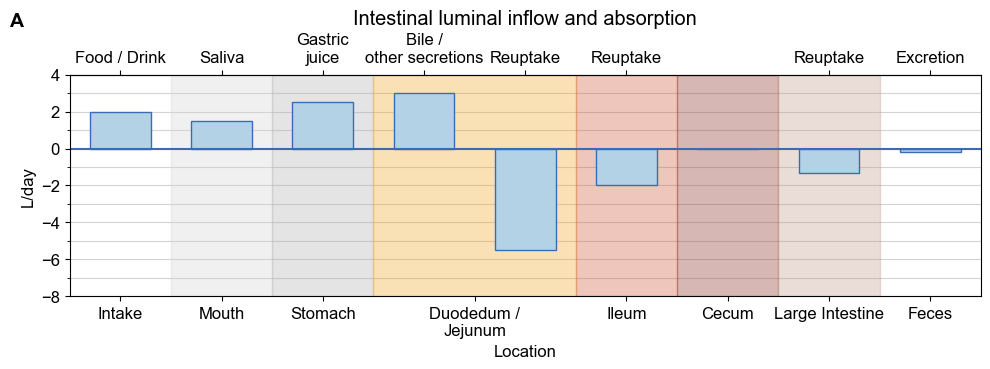

In [91]:
# Flows

# Import data

df= pd.read_csv('flow_abundance_data_analyzed.csv')
df = df.convert_dtypes()

# Define variables

flow_rate_change_data = df['flow_rate_change_L_day'].values # Change in L/day
gut_location = df['gut_location'].values
flow_rate_change_source = df['flow_rate_change_source'].values

# Set up figure
fig,ax=plt.subplots(figsize=(10, 4))

# Plot bars to indicate change in flow rate
ax.bar([0,1,2,3,4,5,6,7,8],flow_rate_change_data,color='#b4d2e6',edgecolor='#396cb6',width=0.6,zorder=2)
ax.axhline(y=0,color='#396cb6') #'gray') 

# Set x tick labels
ax.set_xticks([0,1,2,3.5,5,6,7,8])
ax.set_xticklabels([i.replace('\\n','\n') for i in gut_location.unique()])

# Set top x ticks labels
ax_top = ax.secondary_xaxis('top')
ax_top.set_xticks([0,1,2,3,4,5,7,8])
ax_top.set_xticklabels([i.replace('\\n','\n') for i in np.array(flow_rate_change_source[[True,True,True,True,True,True,False,True,True]])])

# Set y tick labels
ax.set_yticks([-8,-6,-4,-2,0,2,4])
ax.set_yticks([-7,-5,-3,-1,1,3], minor=True)

# Set colors for each region
ax.fill_between(x=[0.5,1.5],y1=-8,y2=4,color=colors_dict['upper'],zorder=1,alpha=0.35)
ax.fill_between(x=[1.5,2.5],y1=-8,y2=4,color=colors_dict['stomach'],zorder=1,alpha=0.35)
ax.fill_between(x=[2.5,4.5],y1=-8,y2=4,color=colors_dict['SI'],zorder=1,alpha=0.35)
ax.fill_between(x=[4.5,5.5],y1=-8,y2=4,color=colors_dict['ileum'],zorder=1,alpha=0.35)
ax.fill_between(x=[5.5,6.5],y1=-8,y2=4,color=colors_dict['cecum'],zorder=1,alpha=0.35)
ax.fill_between(x=[6.5,7.5],y1=-8,y2=4,color=colors_dict['LI'],zorder=1,alpha=0.35)

# Set axes label and ranges
ax.set_ylabel('L/day')
ax.set_xlabel('Location')
ax.set_ylim([-8,4])
ax.set_xlim([-0.5,8.5])
ax.grid(axis='y',color='lightgray',which='both',zorder=0)
ax.set_axisbelow(True)

# Set title and subplot letter
ax.set_title('Intestinal luminal inflow and absorption')
ax.text(-0.05,1.2,'A',fontsize=fontsize+2,transform=ax.transAxes,fontweight="bold",va="bottom",ha="right")

# Save figure
fig.tight_layout()
fig.savefig('figure_1_panel_A.pdf',dpi=1000,transparent=True,bbox_inches="tight")

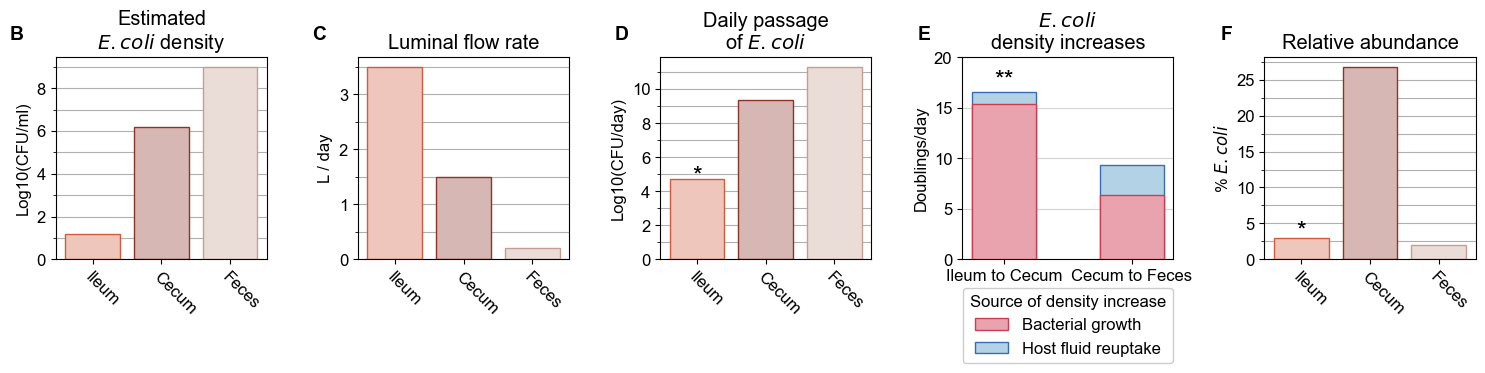

In [98]:
# Define compartments for following plots

x=[0,1,2]
positions=['Ileum','Cecum','Feces']
df_subset=pd.read_csv('flow_abundance_data_subset_analyzed.csv')


fig, axs = plt.subplots(1,5, figsize=(15,4),width_ratios=[1,1,1,1,1])

# 1. Absolute abundance
axs[0].bar(x, df_subset['coliform_density_log_CFU_mL'], color=colors_transparent,edgecolor=colors)
axs[0].set_title("Estimated\n$\it{E. coli}$ density")
axs[0].set_ylabel("Log10(CFU/ml)")
axs[0].set_xticks(x)
axs[0].set_xticklabels(positions, rotation=-45,ha='left',rotation_mode='anchor')
axs[0].yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
axs[0].grid(axis='y',which='both')
axs[0].set_axisbelow(True)

# 2. Flow rate
axs[1].bar(x,df_subset['flow_rate_L_day'],color=colors_transparent,edgecolor=colors) #color=colors_transparent,edgecolor=colors)
axs[1].set_title("Luminal flow rate")
axs[1].set_ylabel("L / day")
axs[1].set_xticks(x)
axs[1].set_xticklabels(positions, rotation=-45,ha='left',rotation_mode='anchor')
axs[1].yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
axs[1].grid(axis='y',which='both')
axs[1].set_axisbelow(True)

# 3. Daily passage
axs[2].bar(x, df_subset['coliform_passage_log_CFU_day'], color=colors_transparent,edgecolor=colors) #color=colors_transparent,edgecolor=colors)
axs[2].set_title("Daily passage\nof $\it{E. coli}$")
axs[2].set_ylabel("Log10(CFU/day)")
axs[2].set_xticks(x)
axs[2].set_xticklabels(positions, rotation=-45,ha='left',rotation_mode='anchor')
axs[2].yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
axs[2].grid(axis='y',which='both')
axs[2].set_axisbelow(True)
axs[2].text(0, 4.5, "*", ha='center',fontsize=18)

# 4. Density increase

width=0.5
x_transition=[0,1]
transition=['Ileum to Cecum','Cecum to Feces']

axs[3].bar(x_transition,df_subset['coliform_density_increase_from_growth_log2'][1:],width=width,color='#E9A3AE',edgecolor='#C93E53',label='Bacterial growth',zorder=3)
axs[3].bar(x_transition,df_subset['coliform_density_increase_log2'][1:],width=width,color='#b4d2e6',edgecolor='#396cb6',label='Host fluid reuptake',zorder=2)
axs[3].set_ylim([0,20])
axs[3].set_xticks(x_transition)
axs[3].set_xticklabels(transition,rotation=0,rotation_mode='anchor')
axs[3].set_ylabel('Doublings/day')
axs[3].grid(axis='y',color='lightgray',which='both',zorder=0)
axs[3].set_axisbelow(True)
axs[3].set_title('$\it{E.coli}$\ndensity increases')
axs[3].text(0, 17, "**", ha='center',fontsize=18)
axs[3].legend(title='Source of density increase',bbox_to_anchor=(0.5,-0.1),loc='upper center',facecolor='white',framealpha=1)


# 5. Relative abundance (linear scale)
axs[4].bar(x, df_subset['coliform_relative_abundance_%'], color=colors_transparent,edgecolor=colors)
axs[4].set_title("Relative abundance")
axs[4].set_ylabel("% $\it{E. coli}$")
axs[4].set_xticks(x)
axs[4].set_xticklabels(positions, rotation=-45,ha='left',rotation_mode='anchor')
axs[4].yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
axs[4].text(0, 3, "*", ha='center',fontsize=18)
axs[4].grid(axis='y',which='both')
axs[4].set_axisbelow(True)


letters=['B','C','D','E','F']

for i in range(len(letters)):
    axs[i].text(-0.15,1.07,letters[i],fontsize=14,transform=axs[i].transAxes,fontweight="bold",va="bottom",ha="right")





fig.tight_layout()


fig.savefig('figure_1_panels_BCDEF.pdf',dpi=1000,bbox_inches="tight",transparent=True)